# Camera Extrinsic Calibration — Conceptual Demo (numpy)

`extrinsic_calibration.md` theory verified hands-on using **numpy only**. No OpenCV required.

1. Projection pipeline `u = K[R|t]` and how the image moves when R·t change
2. Solve PnP with DLT (synthetic data) → compare against ground-truth R, t
3. Epipolar geometry (F matrix and epipolar lines)
4. Stereo rectification → verify that the vertical coordinate v matches for left and right
5. Disparity → depth `Z=fB/d` verification

> For real API usage see `extrinsic_calibration_opencv.ipynb`.

In [1]:
# %pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

def rotx(a): c,s=np.cos(a),np.sin(a); return np.array([[1,0,0],[0,c,-s],[0,s,c]])
def roty(a): c,s=np.cos(a),np.sin(a); return np.array([[c,0,s],[0,1,0],[-s,0,c]])
def rotz(a): c,s=np.cos(a),np.sin(a); return np.array([[c,-s,0],[s,c,0],[0,0,1]])
print('ready')

ready


---

## 1. Projection Pipeline `u = K[R|t]X`

Define intrinsic matrix K and extrinsic [R|t], then project 3D points onto the image.

In [2]:
# Intrinsic parameters
fx=fy=800.0; cx,cy=640.0,360.0
K = np.array([[fx,0,cx],[0,fy,cy],[0,0,1]])

# Extrinsic parameters: world->camera. Place camera in front of the world point cloud.
R = rotx(np.deg2rad(-160))            # Orientation looking downward (example)
C = np.array([0.0, -3.0, 0.0])        # Camera center (world coordinates)
t = -R @ C                            # Translation t = -R C (§2.1)
print('t =', t, '  →  recovered center C=-R^T t =', -R.T@t)

def project(K, R, t, Xw):
    Xw = np.atleast_2d(Xw)
    Xc = (R @ Xw.T + t[:,None]).T      # world->camera
    x = Xc[:, :2] / Xc[:, 2:3]         # Perspective projection (divide by Z)
    u = (K @ np.c_[x, np.ones(len(x))].T).T
    return u[:, :2], Xc[:,2]            # pixel, depth

# Ground grid points (arranged on z=0 plane)
gx, gy = np.meshgrid(np.linspace(-2,2,9), np.linspace(0,6,9))
Xw = np.c_[gx.ravel(), gy.ravel(), np.zeros(gx.size)]
uv, depth = project(K, R, t, Xw)
print('Projected points:', len(uv), ' Depth range:', depth.min().round(2), depth.max().round(2))

t = [ 0.     -2.8191 -1.0261]   →  recovered center C=-R^T t = [ 0. -3.  0.]
Projected points: 81  Depth range: -3.08 -1.03


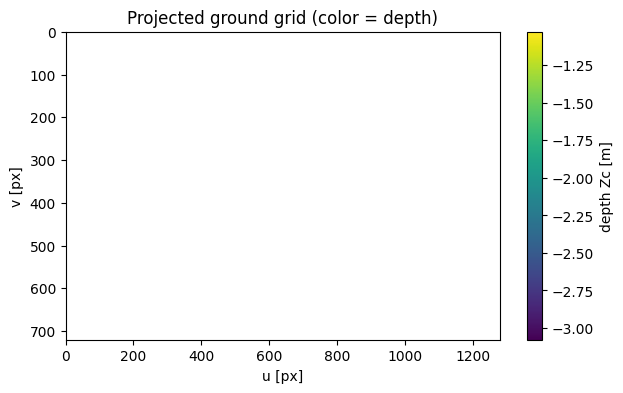

In [3]:
plt.figure(figsize=(7,4))
plt.scatter(uv[:,0], uv[:,1], c=depth, cmap='viridis')
plt.gca().invert_yaxis(); plt.colorbar(label='depth Zc [m]')
plt.xlim(0,1280); plt.ylim(720,0)
plt.title('Projected ground grid (color = depth)'); plt.xlabel('u [px]'); plt.ylabel('v [px]'); plt.show()

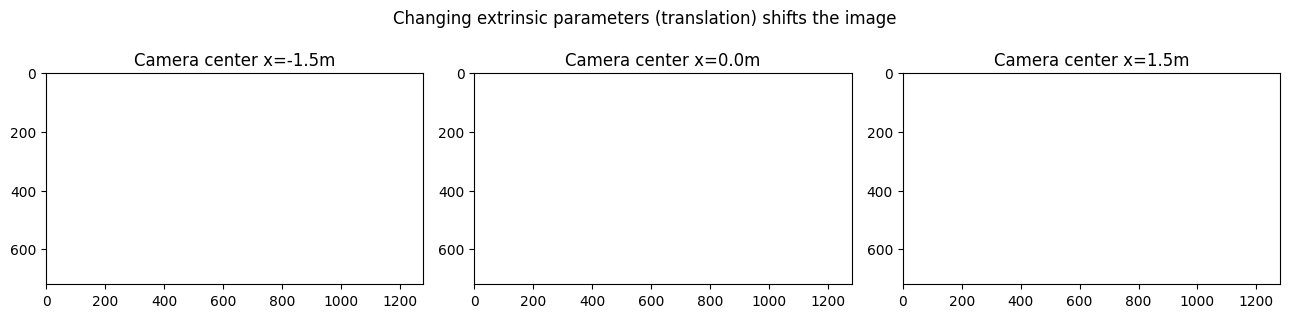

In [4]:
# How the image moves when R,t change: shift camera sideways
fig, axes = plt.subplots(1,3, figsize=(13,3.2))
for ax, dx in zip(axes, [-1.5, 0.0, 1.5]):
    C2 = np.array([dx, -3.0, 0.0]); t2 = -R @ C2
    uv2,_ = project(K, R, t2, Xw)
    ax.scatter(uv2[:,0], uv2[:,1], s=8)
    ax.set_xlim(0,1280); ax.set_ylim(720,0); ax.set_title(f'Camera center x={dx}m')
plt.suptitle('Changing extrinsic parameters (translation) shifts the image'); plt.tight_layout(); plt.show()

---

## 2. Solve PnP with DLT

Given known K, recover `[R|t]` from 3D-2D correspondences (§4.1). Compare against ground truth to verify correctness.

In [5]:
def dlt_pnp(K, Xw, uv):
    # Convert to normalized coordinates (multiply by K^-1)
    Ki = np.linalg.inv(K)
    xn = (Ki @ np.c_[uv, np.ones(len(uv))].T).T[:, :2]
    # Build 2 equations/point from s*[xn,1] = [R|t][Xw,1] to form A p = 0
    A=[]
    for (X,Y,Z),(x,y) in zip(Xw, xn):
        A.append([X,Y,Z,1,0,0,0,0, -x*X,-x*Y,-x*Z,-x])
        A.append([0,0,0,0,X,Y,Z,1, -y*X,-y*Y,-y*Z,-y])
    A=np.array(A)
    _,_,Vt=np.linalg.svd(A)
    M=Vt[-1].reshape(3,4)               # [R|t] (scale undetermined)
    R_=M[:,:3]; t_=M[:,3]
    # Orthogonalize R (SVD) and recover scale
    U,S,Vt2=np.linalg.svd(R_)
    R_ortho=U@Vt2
    scale=1.0/np.mean(S)
    t_=t_*scale
    if np.linalg.det(R_ortho)<0: R_ortho=-R_ortho; t_=-t_
    # Adjust sign so points are in front (Z>0)
    if (R_ortho@Xw[0]+t_)[2] < 0: R_ortho=-R_ortho; t_=-t_
    return R_ortho, t_

# Validate with general-pose ground truth (use non-planar 3D points)
Xw3 = np.random.uniform(-2,2,(30,3)) + np.array([0,0,8.0])
R_gt = rotz(0.2)@roty(-0.15)@rotx(0.1)
t_gt = np.array([0.5,-0.3,1.0])
uv_gt = (K@( (R_gt@Xw3.T+t_gt[:,None]) ))
uv_gt = (uv_gt[:2]/uv_gt[2]).T

R_est, t_est = dlt_pnp(K, Xw3, uv_gt)
print('R error (deg):', np.rad2deg(np.arccos((np.trace(R_gt.T@R_est)-1)/2)).round(4))
print('t ground truth:', t_gt, ' / estimated:', t_est.round(4))

R error (deg): 0.0
t ground truth: [ 0.5 -0.3  1. ]  / estimated: [ 0.5 -0.3  1. ]


In [6]:
# Evaluate with reprojection error
rep = (K@(R_est@Xw3.T+t_est[:,None])); rep=(rep[:2]/rep[2]).T
err = np.linalg.norm(rep-uv_gt, axis=1)
print(f'Reprojection error  mean {err.mean():.4e} px / max {err.max():.4e} px (no noise → nearly 0)')

Reprojection error  mean 3.9992e-13 px / max 6.1222e-13 px (no noise → nearly 0)


---

## 3. Epipolar Geometry

Compute E and F from relative `R,t` of two views and draw epipolar lines (§5).

In [7]:
def skew(v): return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])

# cam1 = reference, cam2 = relative rotation R12 & translation t12
R12 = roty(np.deg2rad(-10))
t12 = np.array([1.0, 0.0, 0.0])         # Mainly horizontal baseline
E = skew(t12) @ R12                       # Essential matrix
F = np.linalg.inv(K).T @ E @ np.linalg.inv(K)   # Fundamental matrix

# Project 3D points onto both cameras
P = np.random.uniform(-2,2,(12,3))+np.array([0,0,8.0])
u1=(K@P.T); u1=(u1[:2]/u1[2]).T
P2=(R12@P.T+t12[:,None]); u2=(K@P2); u2=(u2[:2]/u2[2]).T

# Verify constraint u2^T F u1 = 0
cons=[np.r_[u2[i],1]@F@np.r_[u1[i],1] for i in range(len(P))]
print('Epipolar constraint |u2^T F u1| max:', np.max(np.abs(cons)))

Epipolar constraint |u2^T F u1| max: 1.1102230246251565e-16


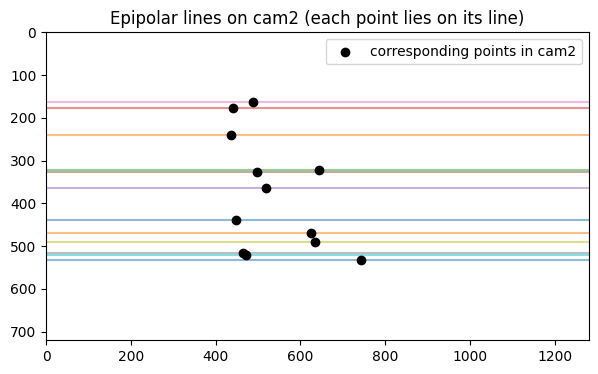

In [8]:
# Draw epipolar lines l2 = F u1 on cam2 image
plt.figure(figsize=(7,4))
xs=np.array([0,1280])
for i in range(len(P)):
    l=F@np.r_[u1[i],1]            # a,b,c : a u + b v + c = 0
    ys=-(l[0]*xs+l[2])/l[1]
    plt.plot(xs,ys,alpha=0.5)
plt.scatter(u2[:,0],u2[:,1],c='k',zorder=3,label='corresponding points in cam2')
plt.xlim(0,1280); plt.ylim(720,0); plt.legend()
plt.title('Epipolar lines on cam2 (each point lies on its line)'); plt.show()

---

## 4. Stereo Rectification

Rotate both cameras to a common `R_rect` and verify that **corresponding points have the same vertical coordinate v** on left and right (§6.2).

In [9]:
# Place 2 cameras in world (offset by baseline, slightly different orientations)
C_l = np.array([0.0,0.0,0.0]); C_r = np.array([0.6,0.0,0.0])   # Baseline 0.6m
R_l = roty(np.deg2rad( 4)); R_r = roty(np.deg2rad(-4))         # Slight convergence
t_l = -R_l@C_l; t_r = -R_r@C_r

# Common rectification rotation R_rect (world coordinates, §6.2)
new_x = (C_r - C_l)/np.linalg.norm(C_r-C_l)        # Baseline direction
opt_l = R_l.T@np.array([0,0,1.0]); opt_r = R_r.T@np.array([0,0,1.0])
old_z = (opt_l+opt_r); old_z/=np.linalg.norm(old_z)
new_y = np.cross(old_z,new_x); new_y/=np.linalg.norm(new_y)
new_z = np.cross(new_x,new_y)
R_rect = np.vstack([new_x,new_y,new_z])            # world->rectified

Knew = K.copy()
def project_rect(C):
    t_=-R_rect@C
    Xc=(R_rect@scene.T+t_[:,None])
    uvw=Knew@Xc; return (uvw[:2]/uvw[2]).T

scene = np.random.uniform(-1.5,1.5,(15,3))+np.array([0,0,7.0])
uvL = project_rect(C_l); uvR = project_rect(C_r)
dv = np.abs(uvL[:,1]-uvR[:,1])
print('Max vertical misalignment after rectification |v_L - v_R|:', dv.max().round(6), 'px → ≈0 means horizontal alignment OK')

Max vertical misalignment after rectification |v_L - v_R|: 0.0 px → ≈0 means horizontal alignment OK


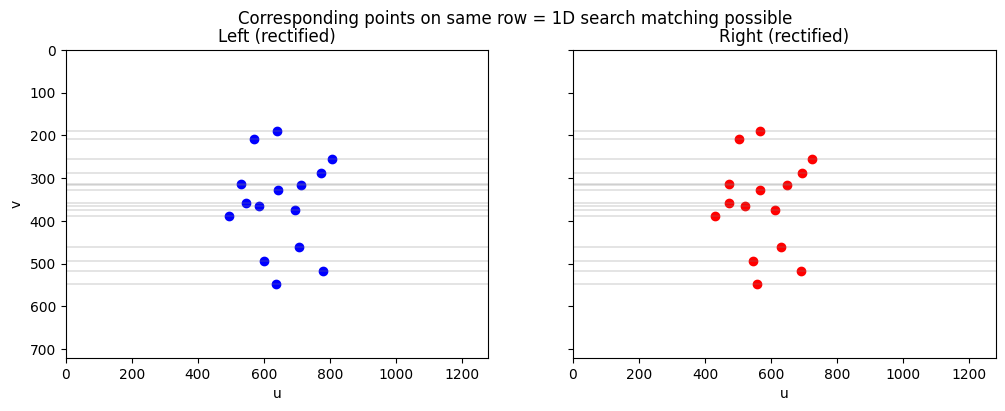

In [10]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4),sharey=True)
a1.scatter(uvL[:,0],uvL[:,1],c='b'); a1.set_title('Left (rectified)')
a2.scatter(uvR[:,0],uvR[:,1],c='r'); a2.set_title('Right (rectified)')
for i in range(len(scene)):                 # horizontal lines at same height
    a1.axhline(uvL[i,1],color='gray',lw=0.3); a2.axhline(uvR[i,1],color='gray',lw=0.3)
for ax in (a1,a2): ax.set_xlim(0,1280); ax.set_ylim(720,0); ax.set_xlabel('u')
a1.set_ylabel('v'); plt.suptitle('Corresponding points on same row = 1D search matching possible'); plt.show()

---

## 5. Disparity → Depth `Z = fB/d`

Recover depth from horizontal pixel difference (disparity) after rectification and verify it matches the true depth (§6.3).

In [11]:
B = np.linalg.norm(C_r-C_l)                # Baseline length
f = Knew[0,0]
disparity = uvL[:,0]-uvR[:,0]              # Disparity
Z_est = f*B/disparity
# True depth (Z in rectified coordinates)
Z_true = (R_rect@(scene.T) - R_rect@C_l[:,None])[2]
for i in range(5):
    print(f'd={disparity[i]:7.2f}px  Z_est={Z_est[i]:6.3f}m  Z_true={Z_true[i]:6.3f}m')
print('Max depth error:', np.abs(Z_est-Z_true).max().round(6),'m')

d=  86.94px  Z_est= 5.521m  Z_true= 5.521m
d=  77.84px  Z_est= 6.166m  Z_true= 6.166m
d=  57.63px  Z_est= 8.329m  Z_true= 8.329m
d=  63.08px  Z_est= 7.609m  Z_true= 7.609m
d=  57.23px  Z_est= 8.387m  Z_true= 8.387m
Max depth error: 0.0 m


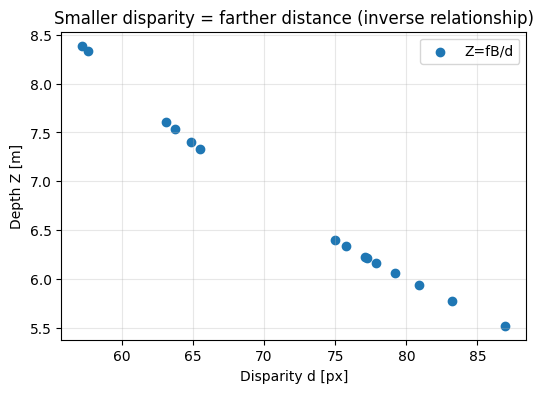

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(disparity, Z_est, label='Z=fB/d')
plt.xlabel('Disparity d [px]'); plt.ylabel('Depth Z [m]')
plt.title('Smaller disparity = farther distance (inverse relationship)'); plt.grid(alpha=0.3); plt.legend(); plt.show()

---

## Summary

- `t` is translation; position is `C=-Rᵀt` (watch the sign)
- Successfully recovered `[R|t]` from known K with DLT (reprojection error ≈ 0)
- Numerically verified epipolar constraint `u₂ᵀFu₁=0` and visualized epipolar lines
- After rectification, left and right `v` match → 1D matching becomes possible
- Correctly recovered depth from disparity via `Z=fB/d`

Next: try the real API in `extrinsic_calibration_opencv.ipynb`.